# Eksperimen Machine Learning - Heart Disease Dataset
**Nama:** Irsyad Adfiansha Hidayat 

**Dataset:** Heart Disease Dataset (Kaggle - johnsmith88)  
**Task:** Binary Classification (target column)

## 1. Perkenalan Dataset
Dataset Heart Disease berisi informasi klinis pasien yang digunakan untuk memprediksi apakah seseorang memiliki penyakit jantung (target=1) atau tidak (target=0). Dataset ini berasal dari UCI ML Repository dan tersedia di Kaggle.

**Fitur:**
- age, sex, cp (chest pain type), trestbps (resting blood pressure)
- chol (cholesterol), fbs (fasting blood sugar), restecg, thalach (max heart rate)
- exang (exercise induced angina), oldpeak, slope, ca, thal
- **target**: 0 = no disease, 1 = disease

## 2. Import Library

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 3. Memuat Dataset

In [ ]:
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
print(f"Dataset downloaded to: {path}")

csv_file = None
for f in os.listdir(path):
    if f.endswith('.csv'):
        csv_file = os.path.join(path, f)
        break

print(f"CSV file: {csv_file}")
df = pd.read_csv(csv_file)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\johnsmith88\heart-disease-dataset\versions\2
CSV file: C:\Users\User\.cache\kagglehub\datasets\johnsmith88\heart-disease-dataset\versions\2\heart.csv
Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
os.makedirs('../heart_disease_raw', exist_ok=True)
df.to_csv('../heart_disease_raw/heart_raw.csv', index=False)
print('Raw dataset saved!')
print(df.dtypes)

Raw dataset saved!
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## 4. Exploratory Data Analysis (EDA)

In [ ]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\n=== First 5 Rows ===')
df.head()

=== Dataset Info ===
Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

=== First 5 Rows ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

=== Missing Values ===
No missing values found!


In [ ]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 723


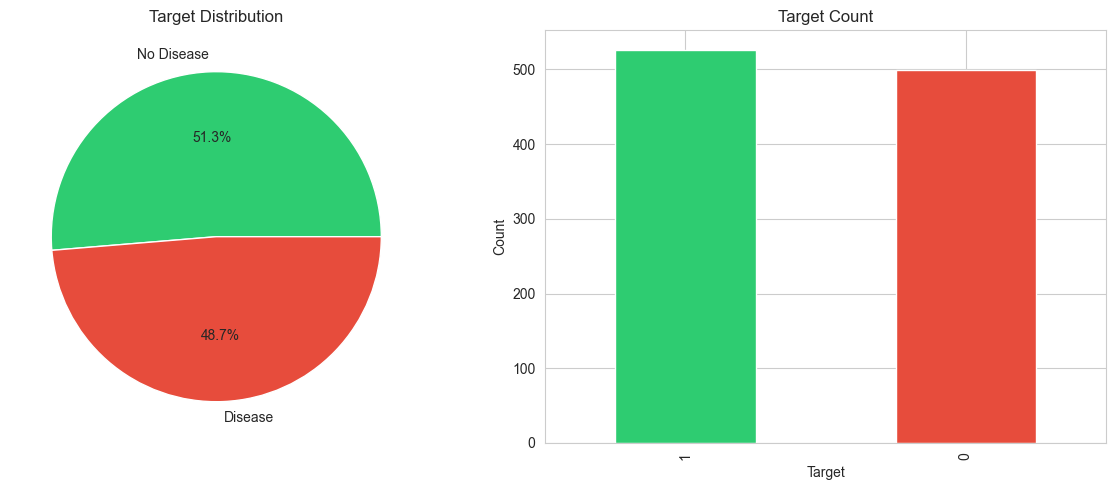

target
1    526
0    499
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['target'].value_counts()
axes[0].pie(target_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0].set_title('Target Distribution')

target_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Target Count')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('../heart_raw/target_distribution.png', dpi=100)
plt.show()
print(target_counts)

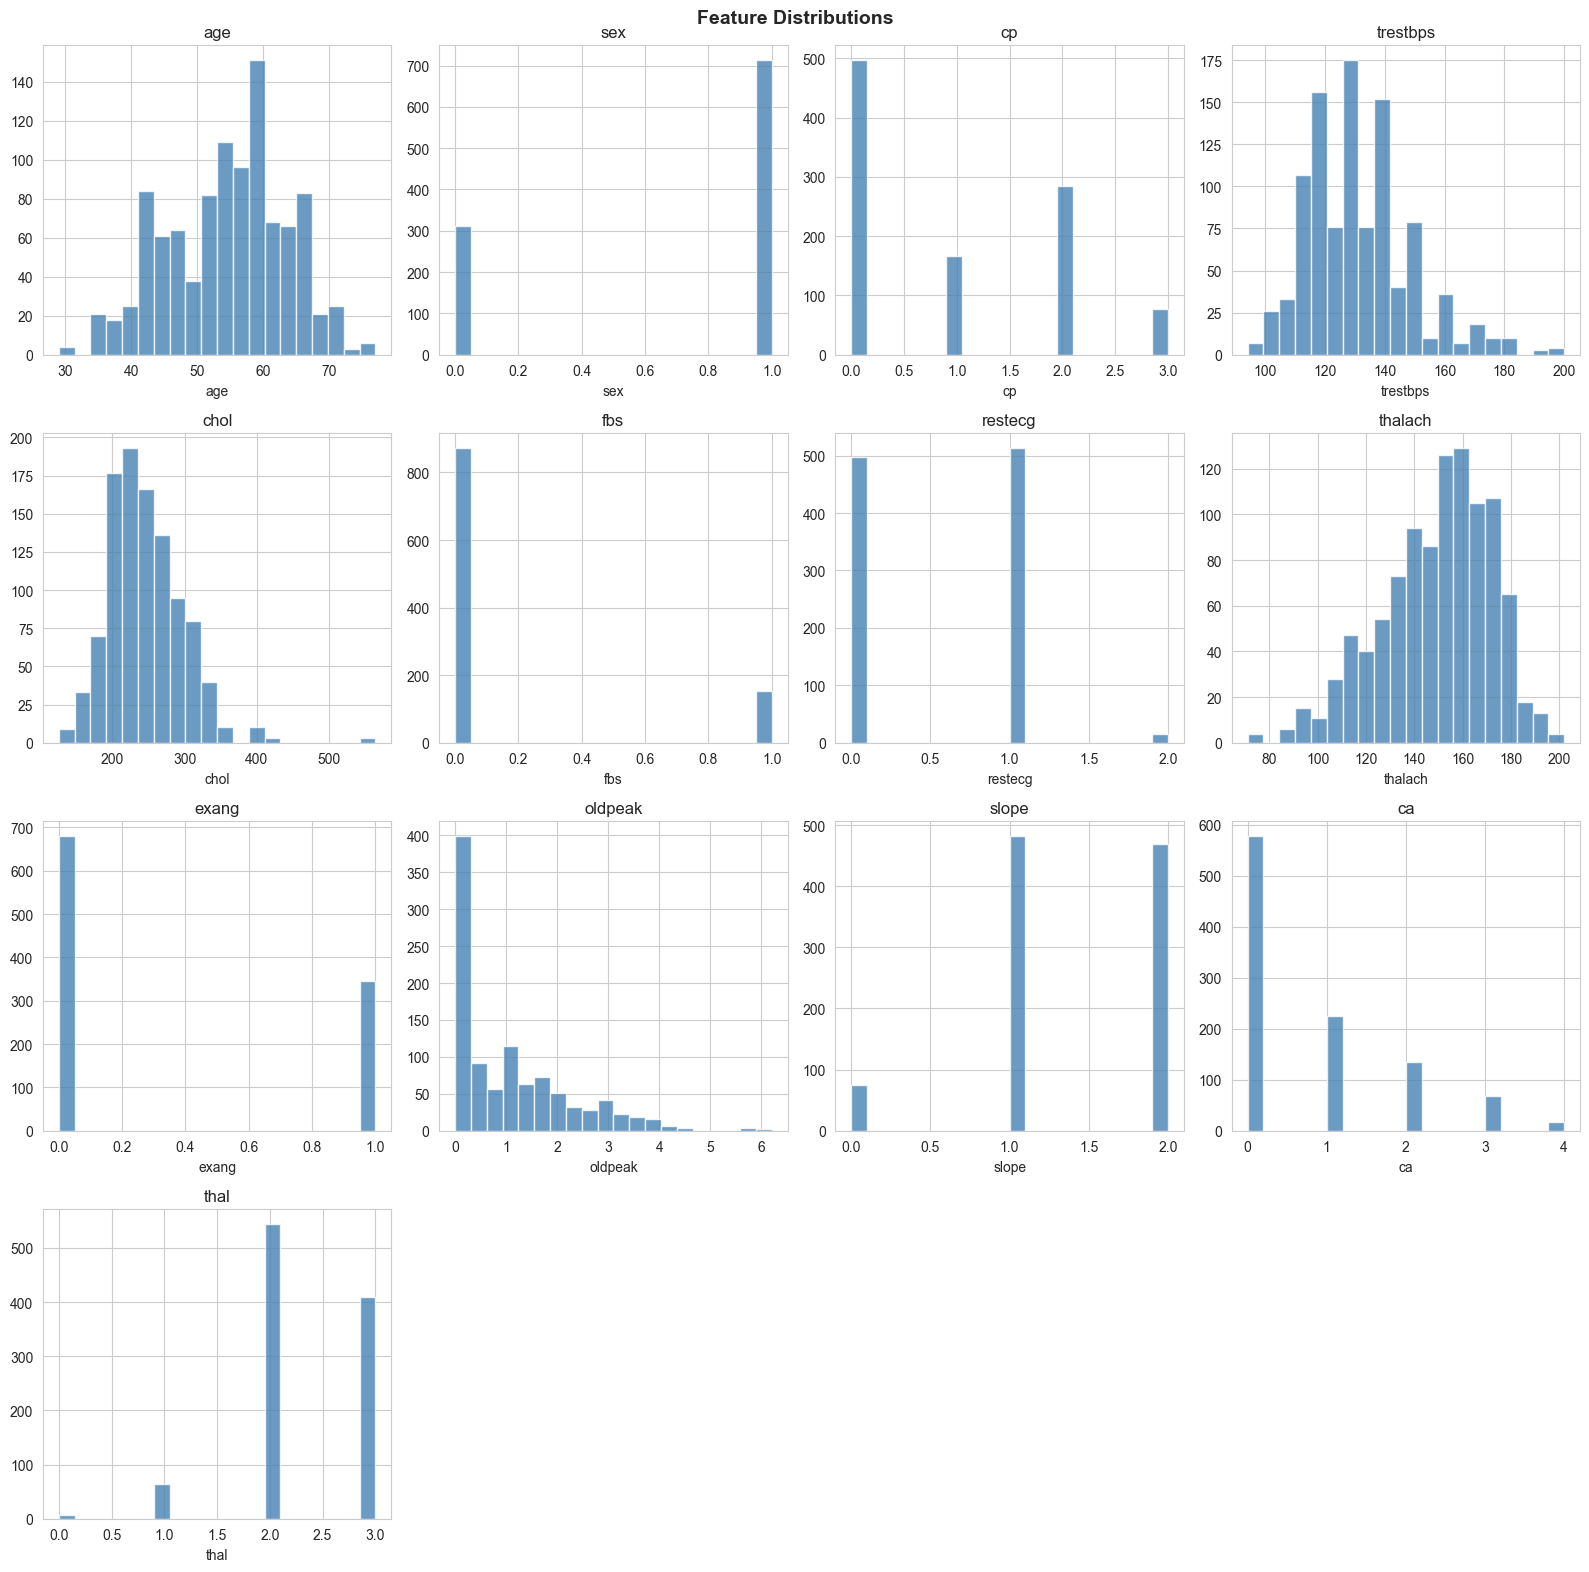

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'target']

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../heart_raw/feature_distributions.png', dpi=100)
plt.show()

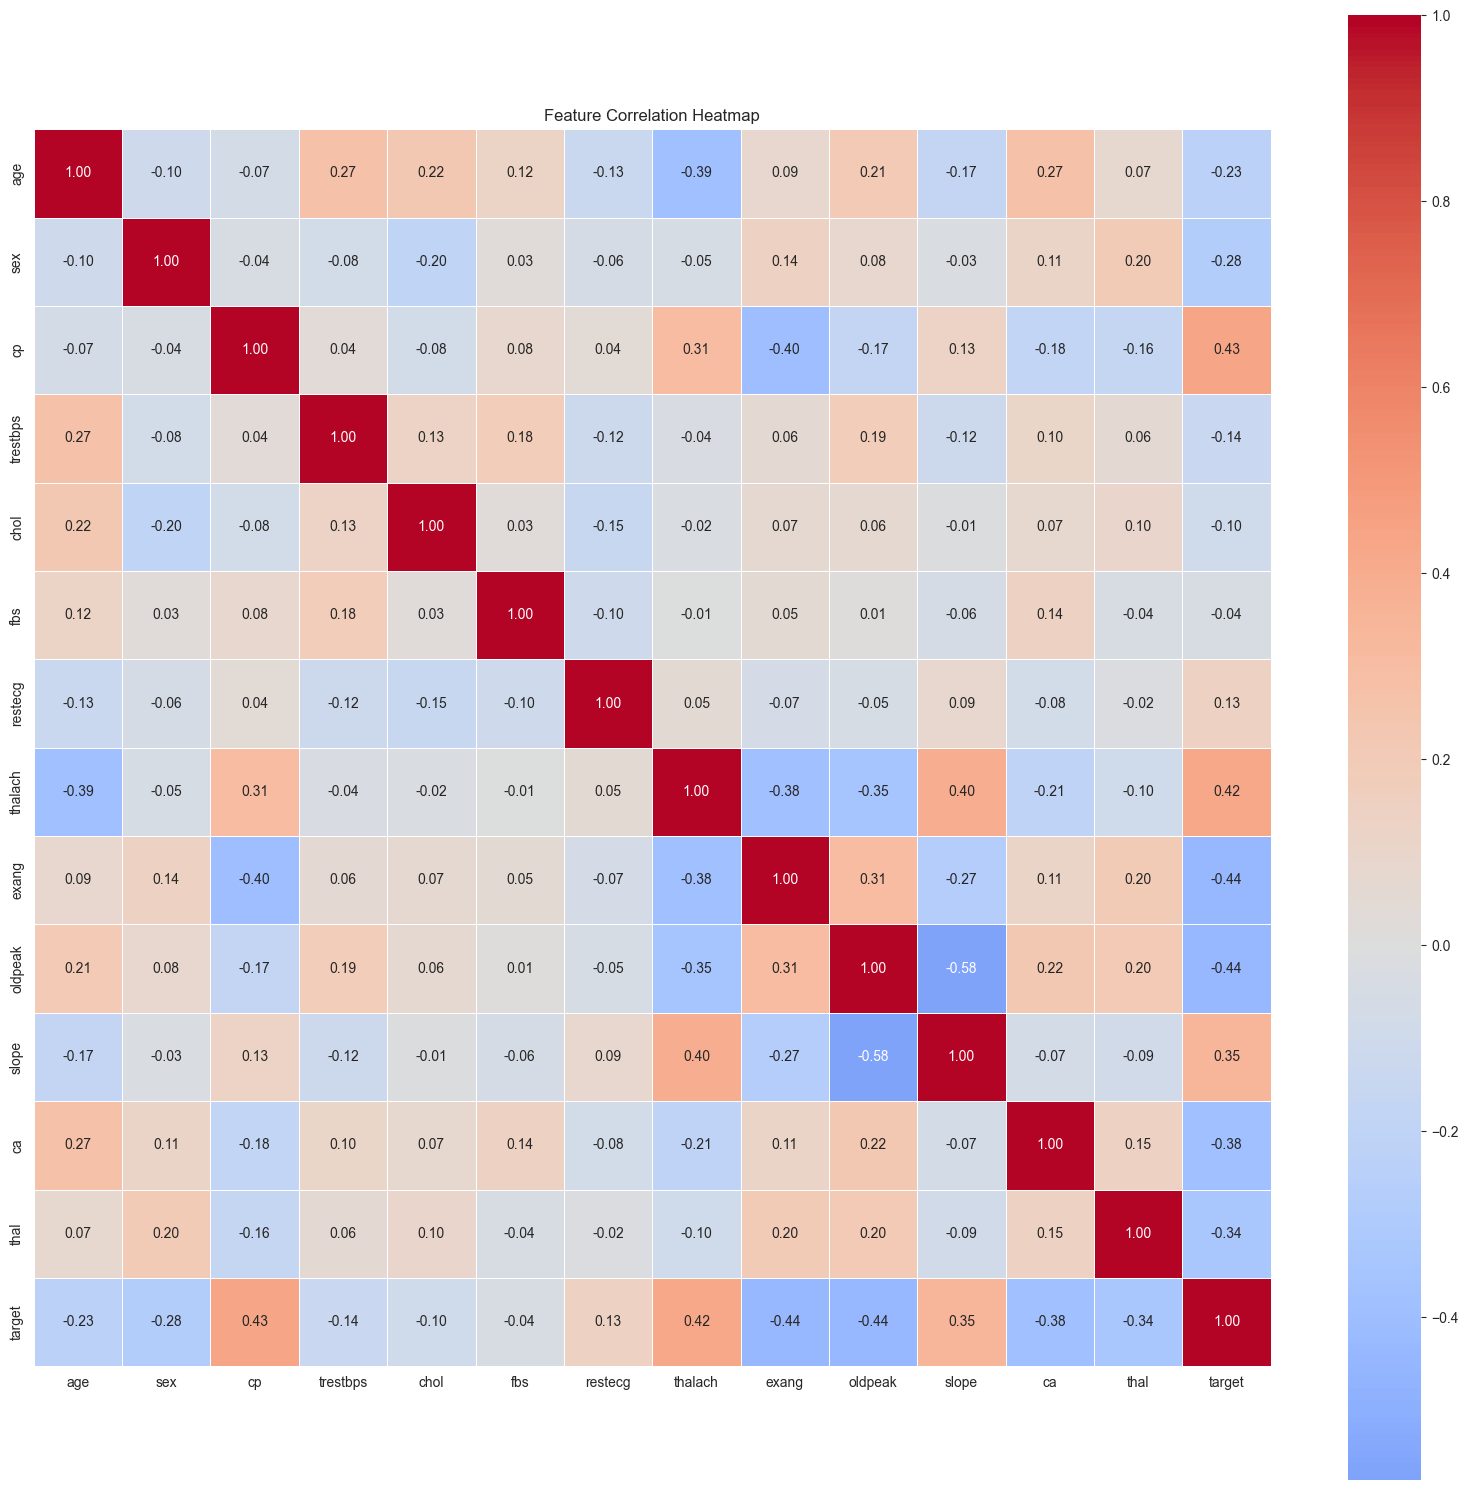

In [ ]:
plt.figure(figsize=(16, 15))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../heart_disease_raw/correlation_heatmap.png', dpi=100)
plt.show()

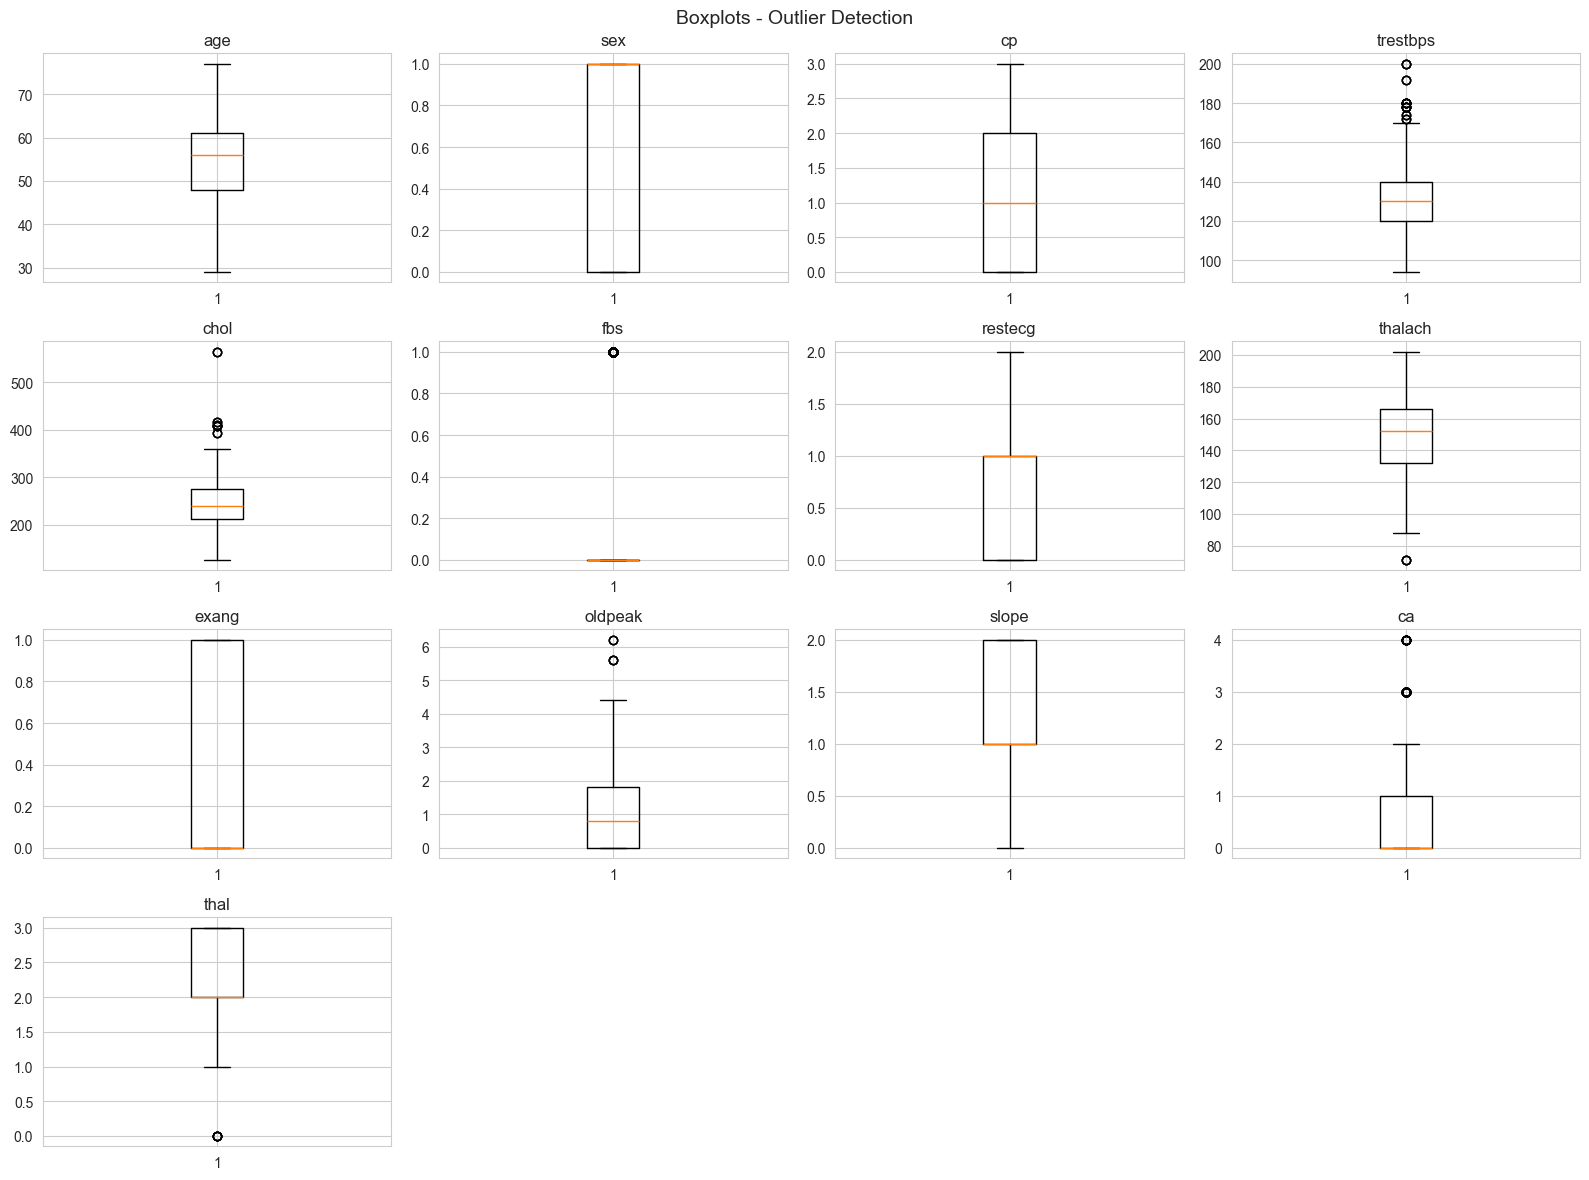

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col}')

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Outlier Detection', fontsize=14)
plt.tight_layout()
plt.savefig('../heart_disease_raw/boxplots.png', dpi=100)
plt.show()

## 5. Data Preprocessing

In [ ]:
print('=== Step 1: Handle Missing Values ===')
df_clean = df.copy()
print(f'Missing values before: {df_clean.isnull().sum().sum()}')

for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Missing values after: {df_clean.isnull().sum().sum()}')

=== Step 1: Handle Missing Values ===
Missing values before: 0
Missing values after: 0


In [ ]:
print('=== Step 2: Remove Duplicates ===')
print(f'Rows before: {len(df_clean)}')
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f'Rows after: {len(df_clean)}')

=== Step 2: Remove Duplicates ===
Rows before: 1025
Rows after: 302


In [ ]:
print('=== Step 3: Handle Outliers (IQR) ===')
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        print(f'{col}: {outliers} outliers clipped')
        df_clean[col] = df_clean[col].clip(lower, upper)

print(f'Shape after outlier handling: {df_clean.shape}')

=== Step 3: Handle Outliers (IQR) ===
age: 0 outliers clipped
trestbps: 9 outliers clipped
chol: 5 outliers clipped
thalach: 1 outliers clipped
oldpeak: 5 outliers clipped
Shape after outlier handling: (302, 14)


In [ ]:
print('=== Step 4: Encoding Categorical Features ===')

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'Encoded: {col}')

if not categorical_cols:
    print('No categorical columns to encode (all numeric)')

=== Step 4: Encoding Categorical Features ===
No categorical columns to encode (all numeric)


In [ ]:
print('=== Step 5: Standardize Features ===')
X = df_clean.drop('target', axis=1)
y = df_clean['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

df_preprocessed = X_scaled_df.copy()
df_preprocessed['target'] = y.values

print(f'Shape of preprocessed data: {df_preprocessed.shape}')
df_preprocessed.head()

=== Step 5: Standardize Features ===
Shape of preprocessed data: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.267966,0.682656,-0.935208,-0.377511,-0.704039,-0.418446,0.901657,0.808993,-0.698344,-0.025091,0.979514,1.274980,1.119967,0
1,-0.157260,0.682656,-0.935208,0.527318,-0.893880,2.389793,-1.002541,0.237018,1.431958,1.869266,-2.271182,-0.714911,1.119967,0
2,1.724733,0.682656,-0.935208,0.828927,-1.505591,-0.418446,0.901657,-1.082925,1.431958,1.418229,-2.271182,-0.714911,1.119967,0
3,0.728383,0.682656,-0.935208,1.009893,-0.893880,-0.418446,0.901657,0.501006,-0.698344,-0.927166,0.979514,0.280034,1.119967,0
4,0.839089,-1.464866,-0.935208,0.406674,1.025627,2.389793,0.901657,-1.918889,-0.698344,0.786777,-0.645834,2.269926,-0.513994,0


In [ ]:
os.makedirs('../heart_disease_preprocessed', exist_ok=True)
df_preprocessed.to_csv('../heart_disease_preprocessed/heart_preprocessed.csv', index=False)
print('Preprocessed dataset saved to heart_disease_preprocessed/heart_preprocessed.csv')
print(f'Final shape: {df_preprocessed.shape}')
df_preprocessed.describe()

Preprocessed dataset saved to heart_preprocessing/heart_preprocessed.csv
Final shape: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,302.000000
mean,-2.676299e-16,-5.881976e-17,-1.058756e-16,4.529122e-16,-1.176395e-16,2.352791e-17,-4.852630e-17,-4.235023e-16,2.352791e-17,1.176395e-17,-3.529186e-17,-4.999680e-17,4.999680e-17,0.543046
std,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,1.001660e+00,0.498970
min,-2.814192e+00,-1.464866e+00,-9.352080e-01,-2.247491e+00,-2.518079e+00,-4.184463e-01,-1.002541e+00,-2.881347e+00,-6.983443e-01,-9.271657e-01,-2.271182e+00,-7.149112e-01,-3.781916e+00,0.000000
25%,-7.107878e-01,-1.464866e+00,-9.352080e-01,-6.791211e-01,-7.251323e-01,-4.184463e-01,-1.002541e+00,-7.199406e-01,-6.983443e-01,-9.271657e-01,-6.458337e-01,-7.149112e-01,-5.139943e-01,0.000000
50%,1.195033e-01,6.826561e-01,3.535150e-02,-7.590177e-02,-1.028744e-01,-4.184463e-01,9.016566e-01,1.270226e-01,-6.983443e-01,-2.055058e-01,-6.458337e-01,-7.149112e-01,-5.139943e-01,1.000000
75%,7.283833e-01,6.826561e-01,1.005911e+00,5.273176e-01,6.195775e-01,-4.184463e-01,9.016566e-01,7.209968e-01,1.431958e+00,5.161541e-01,9.795144e-01,2.800344e-01,1.119967e+00,1.000000
max,2.499671e+00,6.826561e-01,1.976470e+00,2.336976e+00,2.636642e+00,2.389793e+00,2.805854e+00,2.304928e+00,1.431958e+00,2.681134e+00,9.795144e-01,3.264871e+00,1.119967e+00,1.000000


In [30]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64